<a href="https://colab.research.google.com/github/ChipDesignRashid/RISC-Sim-by-Rashid/blob/main/osoc1_core_uarch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assembler functions

In [ ]:
import re

def verify_cpu_results(actual_file, expected_file):
    print(f"\n{'='*20} SPARSE REGRESSION CHECK {'='*20}")

    try:
        with open(actual_file, 'r') as f: actual_lines = f.readlines()
        with open(expected_file, 'r') as f: expected_lines = f.readlines()
    except FileNotFoundError as e:
        print(f"❌ Error: {e}")
        return False

    # 1. Create a Dictionary of ACTUAL values for easy lookup
    # key: "x01", value: the full line string
    actual_map = {}
    for line in actual_lines:
        match = re.search(r'(x\d{2})', line)
        if match:
            actual_map[match.group(1)] = line.strip()

    # 2. Iterate through EXPECTED file and only check what is present
    mismatches = 0
    checks_performed = 0

    for exp_line in expected_lines:
        exp_line = exp_line.strip()
        # Find if this line contains a register name (e.g., x01, x20)
        match = re.search(r'(x\d{2})', exp_line)

        if match:
            reg_name = match.group(1)
            checks_performed += 1

            if reg_name in actual_map:
                act_line = actual_map[reg_name]

                if act_line == exp_line:
                    print(f"✅ {reg_name}: Match! ({act_line.split(':')[-1].strip()})")
                else:
                    mismatches += 1
                    print(f"🚨 {reg_name} MISMATCH:")
                    print(f"   Expected: {exp_line}")
                    print(f"   Actual  : {act_line}")
            else:
                print(f"⚠️  Warning: {reg_name} found in expected file but not in actual dump.")

    # 3. Final Summary
    print(f"{'-'*53}")
    if checks_performed == 0:
        print("❓ No registers found in expected file to verify.")
        return False
    elif mismatches == 0:
        print(f"✨ SUCCESS: All {checks_performed} targeted registers verified!")
        return True
    else:
        print(f"⚠️  FAILURE: {mismatches} out of {checks_performed} checks failed.")
        return False




assembler

In [ ]:
def mini_assembler(asm_line_i):
    """
    Robust RISC-V Assembler with ABI Support & Professional Boundary Checks.
    Supports: addi, lui, add, sub, sll, slt, sltu, xor, srl, sra, or, and, lb, lw, sb, sw
    """
    # 1. Standard RISC-V ABI Register Mapping
    ABI_MAP = {
        'zero': 0, 'ra': 1, 'sp': 2, 'gp': 3, 'tp': 4,
        't0': 5, 't1': 6, 't2': 7, 's0': 8, 'fp': 8, 's1': 9,
        'a0': 10, 'a1': 11, 'a2': 12, 'a3': 13, 'a4': 14, 'a5': 15, 'a6': 16, 'a7': 17,
        's2': 18, 's3': 19, 's4': 20, 's5': 21, 's6': 22, 's7': 23, 's8': 24, 's9': 25, 's10': 26, 's11': 27,
        't3': 28, 't4': 29, 't5': 30, 't6': 31
    }

    def parse_reg(reg_str):
        reg_str = reg_str.lower().strip().replace(',', '')
        if reg_str.startswith('x'):
            return int(reg_str[1:])
        if reg_str in ABI_MAP:
            return ABI_MAP[reg_str]
        raise ValueError(f"Unknown register: {reg_str}")

    def parse_imm(imm_str, bits, is_signed=True):
        """
        The Universal Gatekeeper: Handles decimals, hex bit-patterns, and strict bounds.
        """
        val = int(imm_str, 0)

        if is_signed:
            min_val = -(1 << (bits - 1))
            max_val = (1 << (bits - 1)) - 1

            # Professional Hex Fallback: Convert to signed equivalent (-1) if needed
            if imm_str.lower().startswith('0x') and 0 <= val <= ((1 << bits) - 1):
                if val > max_val:
                    val -= (1 << bits)
        else:
            min_val = 0
            max_val = (1 << bits) - 1

        # The Hardware Crash: Fail loudly if out of bounds
        if not (min_val <= val <= max_val):
            raise ValueError(f"HARDWARE FAULT: Immediate {imm_str} out of {bits}-bit range [{min_val} to {max_val}]")

        return val & ((1 << bits) - 1)

    # 2. Clean the line and Tokenize
    clean_line = asm_line_i.split('#')[0].replace(',', ' ')
    tokens = clean_line.split()

    if not tokens:
        return None

    instr = tokens[0].lower()

    try:
        # --- I-TYPE: ADDI (Opcode: 19) ---
        if instr == "addi":
            rd  = parse_reg(tokens[1])
            rs1 = parse_reg(tokens[2])
            imm_12b = parse_imm(tokens[3], 12, is_signed=True)
            return (imm_12b << 20) | (rs1 << 15) | (0 << 12) | (rd << 7) | 19

        # --- U-TYPE: LUI (Opcode: 55) ---
        elif instr == "lui":
            rd = parse_reg(tokens[1])
            imm_20b = parse_imm(tokens[2], 20, is_signed=False)
            return (imm_20b << 12) | (rd << 7) | 55

        # --- R-TYPE: ALL ALU OPERATIONS (Opcode: 51) ---
        elif instr in ["add", "sub", "sll", "slt", "sltu", "xor", "srl", "sra", "or", "and"]:
            rd  = parse_reg(tokens[1])
            rs1 = parse_reg(tokens[2])
            rs2 = parse_reg(tokens[3])

            # Professional Lookup Table for Hardware Routing (f3, f7)
            rtype_map = {
                "add":  (0, 0x00),
                "sub":  (0, 0x20),
                "sll":  (1, 0x00), # Shift Left Logical
                "slt":  (2, 0x00), # Set Less Than
                "sltu": (3, 0x00), # Set Less Than Unsigned
                "xor":  (4, 0x00), # Bitwise XOR
                "srl":  (5, 0x00), # Shift Right Logical
                "sra":  (5, 0x20), # Shift Right Arithmetic (Preserves Sign)
                "or":   (6, 0x00), # Bitwise OR
                "and":  (7, 0x00)  # Bitwise AND
            }

            f3, f7 = rtype_map[instr]
            return (f7 << 25) | (rs2 << 20) | (rs1 << 15) | (f3 << 12) | (rd << 7) | 51

        # --- I-TYPE: LOADS (Opcode: 3) ---
        elif instr in ["lb", "lw"]:
            rd = parse_reg(tokens[1])
            mem_op = tokens[2].replace(')', '').split('(')
            imm_12b = parse_imm(mem_op[0], 12, is_signed=True)
            rs1 = parse_reg(mem_op[1])
            f3 = 0 if instr == "lb" else 2
            return (imm_12b << 20) | (rs1 << 15) | (f3 << 12) | (rd << 7) | 3

        # --- S-TYPE: STORES (Opcode: 35) ---
        elif instr in ["sb", "sw"]:
            rs2 = parse_reg(tokens[1])
            mem_op = tokens[2].replace(')', '').split('(')
            imm_12b = parse_imm(mem_op[0], 12, is_signed=True)
            rs1 = parse_reg(mem_op[1])
            f3 = 0 if instr == "sb" else 2

            imm_11_5 = (imm_12b >> 5) & 0x7F
            imm_4_0  = imm_12b & 0x1F
            return (imm_11_5 << 25) | (rs2 << 20) | (rs1 << 15) | (f3 << 12) | (imm_4_0 << 7) | 35

       # --- I-TYPE: ALL ALU OPERATIONS (Opcode: 19) ---
        elif instr in ["addi", "slti", "sltiu", "xori", "ori", "andi", "slli", "srli", "srai"]:
            rd  = parse_reg(tokens[1])
            rs1 = parse_reg(tokens[2])
            imm_val = parse_imm(tokens[3], 12, is_signed=True)

            itype_map = {
                "addi":  (0, 0x00),
                "slli":  (1, 0x00),
                "slti":  (2, 0x00),
                "sltiu": (3, 0x00),
                "xori":  (4, 0x00),
                "srli":  (5, 0x00),
                "srai":  (5, 0x20), # 0x20 in the top 7 bits tells the hardware to preserve the sign
                "ori":   (6, 0x00),
                "andi":  (7, 0x00)
            }

            f3, f7_val = itype_map[instr]

            # Hardware Routing: If it's a shift, pack the f7 value into the top of the immediate
            if instr in ["slli", "srli", "srai"]:
                shamt = imm_val & 0x1F # Keep only the bottom 5 bits
                imm_12b = (f7_val << 5) | shamt
            else:
                imm_12b = imm_val & 0xFFF

            return (imm_12b << 20) | (rs1 << 15) | (f3 << 12) | (rd << 7) | 19

            # --- I-TYPE: LOADS (Opcode: 3) ---
        elif instr in ["lb", "lh", "lw", "lbu", "lhu"]:
            rd = parse_reg(tokens[1])
            mem_op = tokens[2].replace(')', '').split('(')
            imm_12b = parse_imm(mem_op[0], 12, is_signed=True)
            rs1 = parse_reg(mem_op[1])

            # The Hardware f3 Routing Map
            load_f3_map = {
                "lb":  0, # 000
                "lh":  1, # 001
                "lw":  2, # 010
                "lbu": 4, # 100 (Unsigned Byte)
                "lhu": 5  # 101 (Unsigned Halfword)
            }
            f3 = load_f3_map[instr]
            return (imm_12b << 20) | (rs1 << 15) | (f3 << 12) | (rd << 7) | 3

        # --- S-TYPE: STORES (Opcode: 35) ---
        elif instr in ["sb", "sh", "sw"]:
            rs2 = parse_reg(tokens[1])
            mem_op = tokens[2].replace(')', '').split('(')
            imm_12b = parse_imm(mem_op[0], 12, is_signed=True)
            rs1 = parse_reg(mem_op[1])

            # The Hardware f3 Routing Map
            store_f3_map = {
                "sb": 0, # 000
                "sh": 1, # 001
                "sw": 2  # 010
            }
            f3 = store_f3_map[instr]

            # S-Type splits the 12-bit immediate: [11:5] and [4:0]
            imm_11_5 = (imm_12b >> 5) & 0x7F
            imm_4_0  = imm_12b & 0x1F
            return (imm_11_5 << 25) | (rs2 << 20) | (rs1 << 15) | (f3 << 12) | (imm_4_0 << 7) | 35
       # --- U-TYPE: AUIPC (Opcode: 23) ---
        # Boundary Check: 20-bit unsigned [0 to 1,048,575]
        elif instr == "auipc":
            rd = parse_reg(tokens[1])
            imm_20b = parse_imm(tokens[2], 20, is_signed=False)
            return (imm_20b << 12) | (rd << 7) | 23

        # --- J-TYPE: JAL (Opcode: 111) ---
        # Boundary Check: 21-bit signed [-1,048,576 to 1,048,574]
        elif instr == "jal":
            rd = parse_reg(tokens[1])
            imm_val = parse_imm(tokens[2], 21, is_signed=True)

            # J-Type Scramble: imm[20|10:1|11|19:12]
            imm_20    = (imm_val >> 20) & 0x1
            imm_19_12 = (imm_val >> 12) & 0xFF
            imm_11    = (imm_val >> 11) & 0x1
            imm_10_1  = (imm_val >> 1)  & 0x3FF
            return (imm_20 << 31) | (imm_10_1 << 21) | (imm_11 << 20) | (imm_19_12 << 12) | (rd << 7) | 111

        # --- I-TYPE: JALR (Opcode: 103) ---
        # Boundary Check: 12-bit signed [-2048 to 2047]
        elif instr == "jalr":
            rd = parse_reg(tokens[1])
            mem_op = tokens[2].replace(')', '').split('(')
            imm_12b = parse_imm(mem_op[0], 12, is_signed=True)
            rs1 = parse_reg(mem_op[1])
            return (imm_12b << 20) | (rs1 << 15) | (0 << 12) | (rd << 7) | 103

        # --- B-TYPE: BRANCHES (Opcode: 99) ---
        # Boundary Check: 13-bit signed [-4096 to 4094]
        elif instr in ["beq", "bne", "blt", "bge", "bltu", "bgeu"]:
            rs1 = parse_reg(tokens[1])
            rs2 = parse_reg(tokens[2])
            imm_val = parse_imm(tokens[3], 13, is_signed=True)

            branch_f3 = {"beq": 0, "bne": 1, "blt": 4, "bge": 5, "bltu": 6, "bgeu": 7}
            f3 = branch_f3[instr]

            # B-Type Scramble: imm[12|10:5|4:1|11]
            imm_12   = (imm_val >> 12) & 0x1
            imm_11   = (imm_val >> 11) & 0x1
            imm_10_5 = (imm_val >> 5)  & 0x3F
            imm_4_1  = (imm_val >> 1)  & 0xF
            return (imm_12 << 31) | (imm_10_5 << 25) | (rs2 << 20) | (rs1 << 15) | (f3 << 12) | (imm_4_1 << 8) | (imm_11 << 7) | 99


    except IndexError:
        print(f"Error parsing line: {asm_line_i} - Missing arguments!")
        return None

    print(f"Unsupported instruction: {instr}")
    return None



In [ ]:
def debug_disassemble(op_o, rd_o, rs1_o, rs2_o, f3_o, f7_o, imm_o):
    """
    Reverse-engineers the hardware wires back into human-readable Assembly.
    """
    # 1. Reverse ABI Mapping for readable registers
    ABI_NAMES = [
        'zero', 'ra', 'sp', 'gp', 'tp', 't0', 't1', 't2',
        's0', 's1', 'a0', 'a1', 'a2', 'a3', 'a4', 'a5',
        'a6', 'a7', 's2', 's3', 's4', 's5', 's6', 's7',
        's8', 's9', 's10', 's11', 't3', 't4', 't5', 't6'
    ]

    def reg(idx):
        return f"x{idx}({ABI_NAMES[idx]})" if 0 <= idx < 32 else f"x{idx}"

    # Sign-extend the 12-bit immediate for display purposes
    # (If the 12th bit is 1, it's negative)
    imm_dec = imm_o if imm_o < 0x800 else imm_o - 0x1000

    # --- I-TYPE: ADDI (Opcode 19) ---
    if op_o == 19:
        return f"addi {reg(rd_o)}, {reg(rs1_o)}, {imm_dec}"

    # --- U-TYPE: LUI (Opcode 55) ---
    elif op_o == 55:
        # LUI immediate is 20 bits; display it beautifully in hex
        return f"lui  {reg(rd_o)}, 0x{imm_o:05x}"

    # --- R-TYPE: ALL ALU OPERATIONS (Opcode 51) ---
    elif op_o == 51:
        # The Hardware Reverse-Lookup Table
        rtype_reverse_map = {
            (0, 0x00): "add",
            (0, 0x20): "sub",
            (1, 0x00): "sll",
            (2, 0x00): "slt",
            (3, 0x00): "sltu",
            (4, 0x00): "xor",
            (5, 0x00): "srl",
            (5, 0x20): "sra",
            (6, 0x00): "or",
            (7, 0x00): "and"
        }

        # Look up the mnemonic based on the f3 and f7 wires
        mnemonic = rtype_reverse_map.get((f3_o, f7_o), "unknown_R")
        return f"{mnemonic:<4} {reg(rd_o)}, {reg(rs1_o)}, {reg(rs2_o)}"

    # --- I-TYPE: LOADS (Opcode 3) ---
    elif op_o == 3:
        mnemonic = "lb" if f3_o == 0 else "lw" if f3_o == 2 else "unknown_L"
        return f"{mnemonic:<4} {reg(rd_o)}, {imm_dec}({reg(rs1_o)})"

    # --- S-TYPE: STORES (Opcode 35) ---
    elif op_o == 35:
        mnemonic = "sb" if f3_o == 0 else "sw" if f3_o == 2 else "unknown_S"
        return f"{mnemonic:<4} {reg(rs2_o)}, {imm_dec}({reg(rs1_o)})"

    # --- I-TYPE: LOADS (Opcode 3) ---
    elif op_o == 3:
        load_rev_map = {0: "lb", 1: "lh", 2: "lw", 4: "lbu", 5: "lhu"}
        mnemonic = load_rev_map.get(f3_o, "unknown_L")
        return f"{mnemonic:<4} {reg(rd_o)}, {imm_dec}({reg(rs1_o)})"

    # --- S-TYPE: STORES (Opcode 35) ---
    elif op_o == 35:
        store_rev_map = {0: "sb", 1: "sh", 2: "sw"}
        mnemonic = store_rev_map.get(f3_o, "unknown_S")
        return f"{mnemonic:<4} {reg(rs2_o)}, {imm_dec}({reg(rs1_o)})"
    # --- U-TYPE: AUIPC (Opcode 23) ---
    elif op_o == 23:
        return f"auipc {reg(rd_o)}, 0x{imm_o:05x}"

    # --- I-TYPE: JALR (Opcode 103) ---
    elif op_o == 103:
        # 12-bit Sign Extension
        imm_dec = imm_o if imm_o < 0x800 else imm_o - 0x1000
        return f"jalr {reg(rd_o)}, {imm_dec}({reg(rs1_o)})"

    # --- J-TYPE: JAL (Opcode 111) ---
    elif op_o == 111:
        # 21-bit Sign Extension for jump target accuracy
        imm_dec = imm_o if imm_o < 0x100000 else imm_o - 0x200000
        return f"jal  {reg(rd_o)}, {imm_dec}"

    # --- B-TYPE: BRANCHES (Opcode 99) ---
    elif op_o == 99:
        # 13-bit Sign Extension for branch target accuracy
        imm_dec = imm_o if imm_o < 0x1000 else imm_o - 0x2000

        branch_rev_map = {0: "beq", 1: "bne", 4: "blt", 5: "bge", 6: "bltu", 7: "bgeu"}
        mnemonic = branch_rev_map.get(f3_o, "unknown_B")
        return f"{mnemonic:<4} {reg(rs1_o)}, {reg(rs2_o)}, {imm_dec}"


    return f"UNKNOWN OPCODE: {op_o}"

Helper Function & Utilities

In [ ]:
# ==========================================
# CELL 1: HELPER FUNCTIONS
# ==========================================
def generate_hex_file(asm_filename, hex_filename):
    """
    Converts assembly source code into a hexadecimal machine code file.
    Returns the total number of instructions assembled.
    """
    total_instr = 0
    try:
        with open(asm_filename, 'r') as asm_in, open(hex_filename, 'w') as hex_out:
            for line in asm_in:
                # Remove comments and whitespace to avoid assembly errors
                clean_line = line.split('#')[0].strip()
                if not clean_line:
                    continue

                machine_code = mini_assembler(clean_line)

                if machine_code is not None and machine_code != 0:
                    # Write as an 8-character hex string (32 bits)
                    hex_string = f"{machine_code & 0xFFFFFFFF:08x}\n"
                    hex_out.write(hex_string)
                    total_instr += 1

        print(f"✅ Success: {hex_filename} generated ({total_instr} instructions).")
        return total_instr

    except FileNotFoundError:
        print(f"❌ Error: {asm_filename} not found.")
        return 0


def to_signed_32(val_i):
    """
    Evaluates a 32-bit hardware wire as a signed integer.
    Enforces the negative minimum bound for Two's Complement math.
    """
    # Enforce maximum 32-bit wire limit
    val = val_i & 0xFFFFFFFF
    # Check if the 31st bit (Sign) is 1
    if val & 0x80000000:
        return val - 0x100000000 # Map to negative minimum bound
    return val

Hardware State (Memory & Registers)

In [ ]:
# ==========================================
# CELL 2: HARDWARE STATE (Storage Elements)
# ==========================================
class PCState:
    """Physical storage for the Program Counter Flip-Flop"""
    def __init__(self):
        self.current_pc = 0x00000000

    def update(self, val):
        # Hardware Constraint: PC must be between minimum (0x0) and maximum (0xFFFFFFFF)
        if val < 0x00000000 or val > 0xFFFFFFFF:
            raise ValueError(f"HARDWARE FAULT: PC Address Out of Bounds (0x{val:08x})")
        self.current_pc = val

    def read(self):
        return self.current_pc

class RegisterFile:
    def __init__(self):
        # Initialize 32 registers to 0
        self.registers = [0] * 32

    def read_rs1(self, addr):
        """Port RD1: Combinational Read"""
        return 0 if addr == 0 else self.registers[addr] & 0xFFFFFFFF

    def read_rs2(self, addr):
        """Port RD2: Combinational Read"""
        return 0 if addr == 0 else self.registers[addr] & 0xFFFFFFFF

    def write(self, addr, data, we):
        """Port WD: Sequential Write with x0 Protection"""
        # Hardware 'Safety Gate': x0 cannot be overwritten
        if we and addr != 0:
            self.registers[addr] = data & 0xFFFFFFFF

class DataMemory:
    """
    Simulated SRAM Macro with 4-bit Write Strobe Support.
    Uses a sparse dictionary for infinite, memory-safe addressing.
    """
    def __init__(self):
        # Keys are 32-bit aligned addresses, Values are 32-bit words
        self.memory = {}

    def read(self, address_i):
        # Hardware enforces word-alignment by ignoring the bottom 2 bits
        base_addr = address_i & 0xFFFFFFFC
        return self.memory.get(base_addr, 0)

    def write(self, address_i, write_data_i, we_i):
        if we_i == 0:
            return

        base_addr = address_i & 0xFFFFFFFC

        # Read the current word from memory (or 0 if it's empty)
        current_word = self.memory.get(base_addr, 0)
        new_word = current_word

        # --- THE HARDWARE BYTE MASKS ---
        # Only overwrite the specific bytes authorized by the 4-bit strobe (we_i)

        # Byte 0 (Bits 7:0)
        if (we_i & 0b0001):
            new_word = (new_word & 0xFFFFFF00) | (write_data_i & 0x000000FF)

        # Byte 1 (Bits 15:8)
        if (we_i & 0b0010):
            new_word = (new_word & 0xFFFF00FF) | (write_data_i & 0x0000FF00)

        # Byte 2 (Bits 23:16)
        if (we_i & 0b0100):
            new_word = (new_word & 0xFF00FFFF) | (write_data_i & 0x00FF0000)

        # Byte 3 (Bits 31:24)
        if (we_i & 0b1000):
            new_word = (new_word & 0x00FFFFFF) | (write_data_i & 0xFF000000)

        # Commit the surgically modified word back to memory
        self.memory[base_addr] = new_word

# ==========================================
# CELL 2 UPDATE: Add Hex File Loading
# ==========================================

class InstructionMemory:
    def __init__(self):
        self.memory = {}

    def load_instruction(self, address_i, instruction_i):
        addr = address_i & 0xFFFFFFFF
        self.memory[addr] = instruction_i & 0xFFFFFFFF

    def load_from_hex_file(self, filename_i):
        """Mimics the SystemVerilog $readmemh system task."""
        addr = 0x00000000
        with open(filename_i, 'r') as f:
            for line in f:
                clean_line = line.strip()
                if clean_line:
                    # Parse the hex string and enforce 32-bit maximum hardware boundary
                    instruction = int(clean_line, 16) & 0xFFFFFFFF
                    self.memory[addr] = instruction
                    # Advance to the next 32-bit word address
                    addr += 4

    def read(self, pc_i):
        addr = pc_i & 0xFFFFFFFF
        return self.memory.get(addr, 0)

Decoder, Immediate generator, branch control unit, load & store alignment units

In [ ]:
def module_pc_plus_4(pc_curr):
    """
    Standalone PC+4 Adder.
    In Hardware: A dedicated 32-bit incrementer.
    """
    return (pc_curr + 4) & 0xFFFFFFFF

IMM GENERATOR, SAU, LAU

In [ ]:
# ==========================================
# LOAD ALIGNMENT UNIT (LAU)
# ==========================================

def module_lau(raw_mem_data_i, adrs_1_i, adrs_0_i, funct3_i):
    """
    Extracts bytes/halfwords from a 32-bit memory word and enforces sign-extensions.
    """
    # Combine the bottom two address wires to find the byte offset (0, 1, 2, or 3)
    byte_offset = (adrs_1_i << 1) | adrs_0_i

    # Shift the raw 32-bit memory word so our target data is at the very bottom
    shifted_data = (raw_mem_data_i >> (byte_offset * 8)) & 0xFFFFFFFF

    if funct3_i == 0x0: # LB (Load Byte - Signed)
        val = shifted_data & 0xFF # Enforce 8-bit maximum hardware limit
        if val & 0x80:            # Check the 8th wire (sign bit)
            return val | 0xFFFFFF00
        return val

    elif funct3_i == 0x1: # LH (Load Halfword - Signed)
        val = shifted_data & 0xFFFF # Enforce 16-bit maximum hardware limit
        if val & 0x8000:            # Check the 16th wire (sign bit)
            return val | 0xFFFF0000
        return val

    elif funct3_i == 0x2: # LW (Load Word)
        return shifted_data & 0xFFFFFFFF # Enforce absolute 32-bit limit

    elif funct3_i == 0x4: # LBU (Load Byte - Unsigned)
        return shifted_data & 0xFF # Zero-extend by naturally masking

    elif funct3_i == 0x5: # LHU (Load Halfword - Unsigned)
        return shifted_data & 0xFFFF # Zero-extend by naturally masking

    return 0

  # ==========================================
# STORE ALIGNMENT UNIT (SAU)
# ==========================================

def module_sau(rd2_data_i, adrs_1_i, adrs_0_i, funct3_i):
    """
    Positions data for writing and generates the 4-bit byte enable mask.
    """
    byte_offset = (adrs_1_i << 1) | adrs_0_i

    aligned_data_o = 0
    byte_mask_o = 0 # 4-bit mask (0000 to 1111)

    if funct3_i == 0x0: # SB (Store Byte)
        # Isolate the bottom 8 bits of the register to enforce minimum width
        data = rd2_data_i & 0xFF
        aligned_data_o = (data << (byte_offset * 8)) & 0xFFFFFFFF
        byte_mask_o = (0x1 << byte_offset) & 0xF

    elif funct3_i == 0x1: # SH (Store Halfword)
        # Isolate the bottom 16 bits of the register
        data = rd2_data_i & 0xFFFF
        aligned_data_o = (data << (byte_offset * 8)) & 0xFFFFFFFF
        byte_mask_o = (0x3 << byte_offset) & 0xF

    elif funct3_i == 0x2: # SW (Store Word)
        aligned_data_o = rd2_data_i & 0xFFFFFFFF
        byte_mask_o = 0xF # 1111 -> Write all 4 bytes

    return aligned_data_o, byte_mask_o


ALU

In [ ]:
def module_alu(src1_i, src2_i, alu_op_i):
    """
    Arithmetic Logic Unit (ALU) - Full RV32I Base Integer Support
    """
    # 1. Unsigned 32-bit wire boundaries
    a_i = src1_i & 0xFFFFFFFF
    b_i = src2_i & 0xFFFFFFFF

    # 2. Signed conversion for hardware flag checks and Arithmetic Shifts
    a_s = a_i if a_i < 0x80000000 else a_i - 0x100000000
    b_s = b_i if b_i < 0x80000000 else b_i - 0x100000000

    res_o = 0
    carry_o = 0
    ovfl_o = 0

    # 3. The ALU Core Execution (The Big Multiplexer)
    if alu_op_i == "ADD":
        res_o = a_i + b_i
        carry_o = 1 if res_o > 0xFFFFFFFF else 0
        ovfl_o = 1 if (a_s > 0 and b_s > 0 and (a_s + b_s) <= 0) or \
                      (a_s < 0 and b_s < 0 and (a_s + b_s) >= 0) else 0

    elif alu_op_i == "SUB":
        res_o = a_i - b_i
        carry_o = 1 if a_i >= b_i else 0 # Unsigned borrow
        ovfl_o = 1 if (a_s > 0 and b_s < 0 and (a_s - b_s) <= 0) or \
                      (a_s < 0 and b_s > 0 and (a_s - b_s) >= 0) else 0

    # Bitwise Operations
    elif alu_op_i == "AND":
        res_o = a_i & b_i
    elif alu_op_i == "OR":
        res_o = a_i | b_i
    elif alu_op_i == "XOR":
        res_o = a_i ^ b_i

    # Shift Operations (RISC-V only looks at the bottom 5 bits of the shift amount)
    elif alu_op_i == "SLL":  # Shift Left Logical
        shift_amt = b_i & 0x1F
        res_o = a_i << shift_amt

    elif alu_op_i == "SRL":  # Shift Right Logical (Fills with 0s)
        shift_amt = b_i & 0x1F
        res_o = a_i >> shift_amt

    elif alu_op_i == "SRA":  # Shift Right Arithmetic (Preserves Sign Bit)
        shift_amt = b_i & 0x1F
        # We use the signed version (a_s) here because Python natively
        # sign-extends negative integers when using >>
        res_o = a_s >> shift_amt

    # Comparison Operations
    elif alu_op_i == "SLT":  # Set Less Than (Signed)
        res_o = 1 if a_s < b_s else 0

    elif alu_op_i == "SLTU": # Set Less Than Unsigned
        res_o = 1 if a_i < b_i else 0

    else:
        # Pass-through or unhandled opcode fallback
        res_o = b_i

    # 4. Final output wire masking and Zero/Sign flag generation
    final_res_o = res_o & 0xFFFFFFFF
    z_o = 1 if final_res_o == 0 else 0
    s_o = (final_res_o >> 31) & 1

    # 5. Logic Analyzer Trace
    flag_str = f"Z:{z_o} S:{s_o} V:{ovfl_o} C:{carry_o}"
    print("\n--- Inside ALU-------")
    print(f"ALU-CORE | A: 0x{a_i:08x} | B: 0x{b_i:08x} | OP: {alu_op_i:<4}")
    print(f"ALU-OUT  | RES: 0x{final_res_o:08x} | FLAGS: [{flag_str}]\n")

    return final_res_o, z_o, s_o, ovfl_o, carry_o


In [ ]:
def module_ctrl(opcode_i, funct3_i, funct7_i):
    """
    Audited RV32I Control Unit.
    Logic mapped to 'Chip Design with Rashid' Microarchitecture.
    """
    op = opcode_i & 0x7F

    # --- Hardware Defaults (Reset State) ---
    is_cond_branch_o, is_jal_o, is_jalr_o = 0, 0, 0
    imm_src_o, alu_src1_ctrl_o, alu_src2_ctrl_o = 0, 1, 0
    alu_ctrl_o = "ADD"
    datamem_re_o, datamem_we_o, dataMem2Reg_o, regfile_we_o = 0, 0, 0, 0

    # --- Instruction Decoding Logic ---

    if op == 51:    # 0x33: R-TYPE (Reg-Reg)
        regfile_we_o = 1
        if funct3_i == 0 and funct7_i == 32: alu_ctrl_o = "SUB"  # sub
        elif funct3_i == 0: alu_ctrl_o = "ADD"                  # add
        elif funct3_i == 1: alu_ctrl_o = "SLL"                  # sll
        elif funct3_i == 2: alu_ctrl_o = "SLT"                  # slt
        elif funct3_i == 3: alu_ctrl_o = "SLTU"                 # sltu
        elif funct3_i == 4: alu_ctrl_o = "XOR"                  # xor
        elif funct3_i == 5 and funct7_i == 32: alu_ctrl_o = "SRA" # sra
        elif funct3_i == 5: alu_ctrl_o = "SRL"                  # srl
        elif funct3_i == 6: alu_ctrl_o = "OR"                   # or
        elif funct3_i == 7: alu_ctrl_o = "AND"                  # and

    elif op == 19:  # 0x13: I-TYPE (Reg-Imm)
        regfile_we_o, alu_src2_ctrl_o = 1, 1
        if funct3_i == 0: alu_ctrl_o = "ADD"                    # addi
        elif funct3_i == 2: alu_ctrl_o = "SLT"                  # slti
        elif funct3_i == 3: alu_ctrl_o = "SLTU"                 # sltiu
        elif funct3_i == 4: alu_ctrl_o = "XOR"                  # xori
        elif funct3_i == 6: alu_ctrl_o = "OR"                   # ori
        elif funct3_i == 7: alu_ctrl_o = "AND"                  # andi
        elif funct3_i == 1: alu_ctrl_o = "SLL"                  # slli
        elif funct3_i == 5:
            if funct7_i == 32: alu_ctrl_o = "SRA"               # srai
            else: alu_ctrl_o = "SRL"                            # srli

    elif op == 3:   # 0x03: LOAD
        regfile_we_o, alu_src2_ctrl_o, datamem_re_o, dataMem2Reg_o = 1, 1, 1, 1

    elif op == 35:  # 0x23: STORE
        imm_src_o, alu_src2_ctrl_o, datamem_we_o = 1, 1, 1

    elif op == 99:  # 0x63: BRANCH
        is_cond_branch_o, imm_src_o, alu_ctrl_o = 1, 2, "SUB"

    elif op == 55:  # 0x37: LUI (Load Upper Imm)
        # src1=2 (Zero), src2=1 (Imm), imm_src=3 (U-type)
        regfile_we_o, imm_src_o, alu_src1_ctrl_o, alu_src2_ctrl_o = 1, 3, 2, 1

    elif op == 23:  # 0x17: AUIPC (Add Upper Imm to PC)
        # src1=0 (PC), src2=1 (Imm), imm_src=3 (U-type)
        regfile_we_o, imm_src_o, alu_src1_ctrl_o, alu_src2_ctrl_o = 1, 3, 0, 1

    elif op == 103: # 0x67: JALR
        is_jalr_o, regfile_we_o, alu_src1_ctrl_o, alu_src2_ctrl_o, alu_ctrl_o, dataMem2Reg_o = 1, 1, 1, 1, "ADD", 2

    elif opcode_i == 111: # 0x6F: JAL
        is_jal_o, regfile_we_o, imm_src_o, dataMem2Reg_o, datamem_re_o, datamem_we_o = 1, 1, 4, 2, 0, 0

    # Inside module_ctrl, just before the final 'return signals_o'
    print(f"\n--- inside the module module_ctrl ---")
    print(f"INPUTS  | op_i: {opcode_i} | f3_i: {funct3_i} | f7_i: {funct7_i}\n"
          f"OUTPUTS | Mem: [RE:{datamem_re_o}, WE:{datamem_we_o}]\n"
          f"        | BCU [IS-COND-BRANCH:{is_cond_branch_o}, IS_JAL:{is_jal_o}, IS_JALR:{is_jalr_o}]\n"
          f"        | Data: [ImmSrc:{imm_src_o}, S1:{alu_src1_ctrl_o}, S2:{alu_src2_ctrl_o}, ALU:{alu_ctrl_o}, D2R:{dataMem2Reg_o}, RFWE:{regfile_we_o}]")

    return (is_cond_branch_o, is_jal_o, is_jalr_o, imm_src_o,
            alu_src1_ctrl_o, alu_src2_ctrl_o, alu_ctrl_o,
            datamem_re_o, datamem_we_o, dataMem2Reg_o, regfile_we_o)


Top-Level Datapath Integration

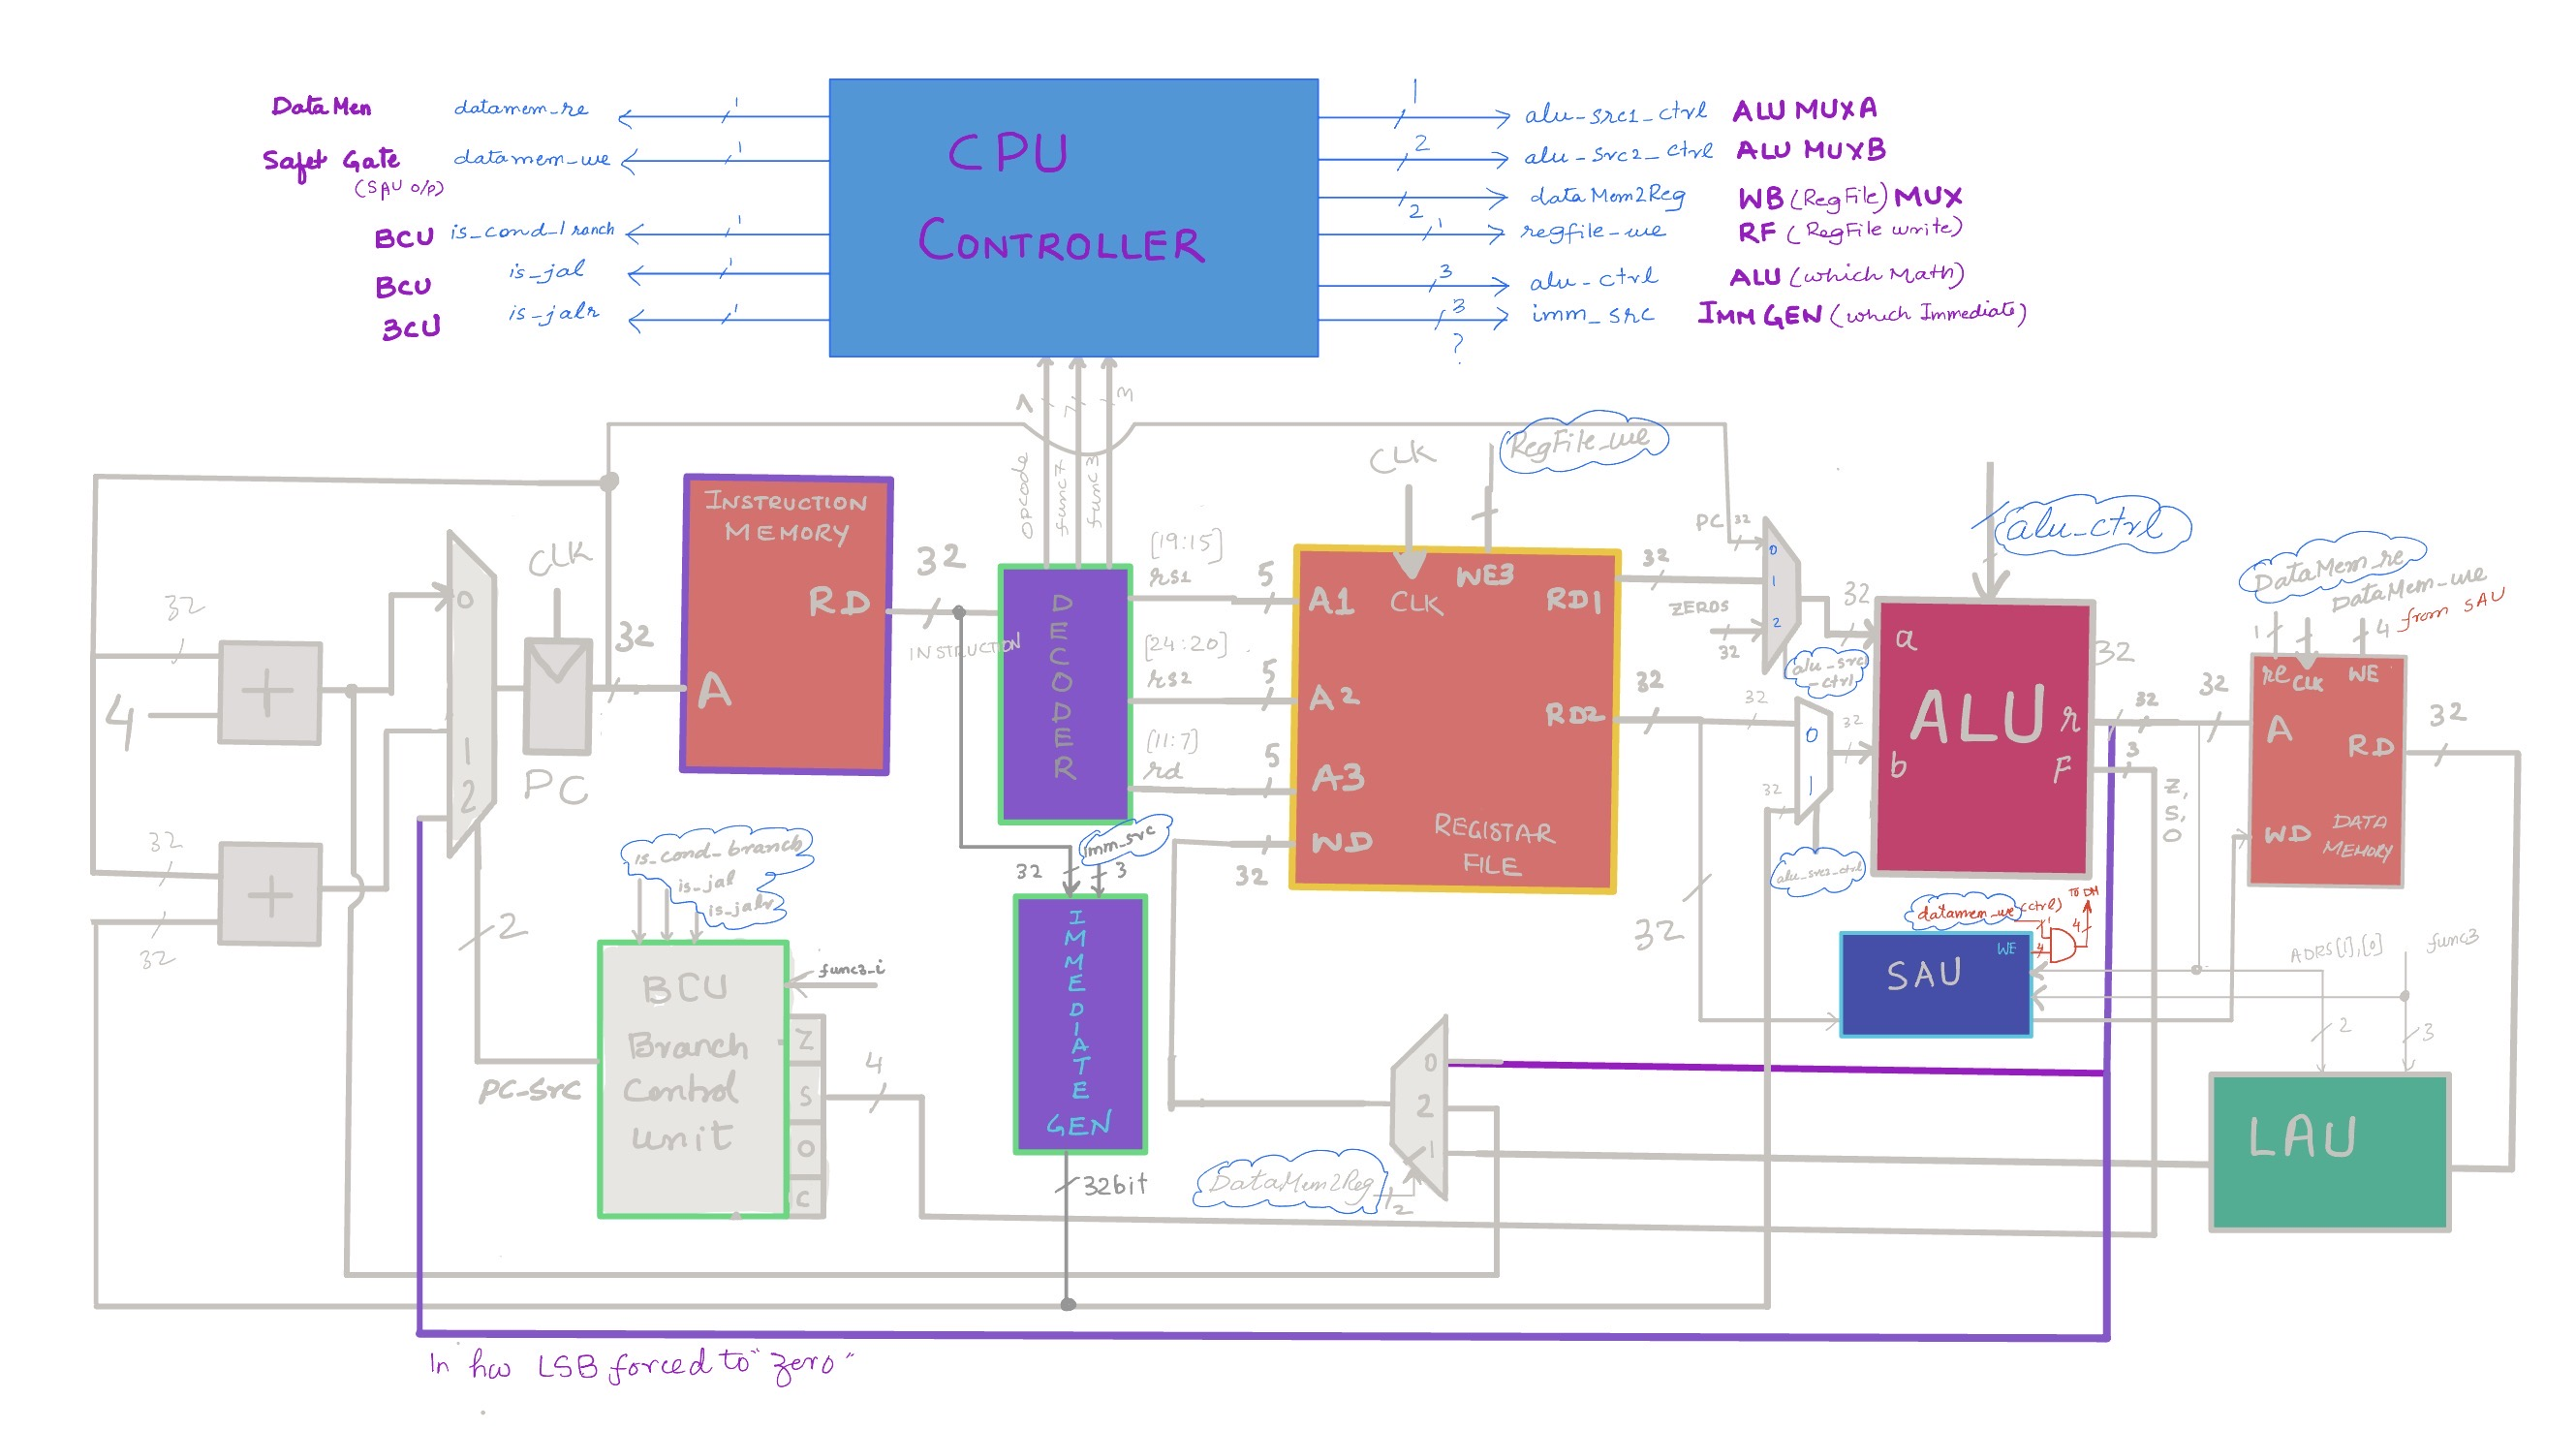

Register File

In [ ]:
def module_register_file(rs1_addr_i, rs2_addr_i, rd_addr_i, rd_data_i, rf_we_i, reg_file_obj):
    """
    Register File (Mapped to Physical RegFile Object)
    Handles 2 Reads and 1 Write per cycle.
    """


    # 1. READ PORT 1 & 2
    # Logic: rs1_addr_i and rs2_addr_i are 5-bit pointers (0-31)
    rs1_val_o = reg_file_obj.read_rs1(rs1_addr_i)
    rs2_val_o = reg_file_obj.read_rs2(rs2_addr_i)

    # 2. WRITE PORT (Only on Clock Edge if WE is high)
    # Hardware Note: x0 is hardwired to 0. Logic inside the object handles this,
    # but we can print a check here.
    if rf_we_i and rd_addr_i != 0:
        reg_file_obj.write(rd_addr_i, rd_data_i, rf_we)
        print(f"ACTION  | Writing 0x{rd_data_i:08x} to x{rd_addr_i}")
    elif rf_we_i and rd_addr_i == 0:
        print(f"ACTION  | Attempted write to x0 ignored (Hardwired to 0)")

    print ("\n**** Inside RF ******")
    print(f"INPUTS  | rs1_addr: {rs1_addr_i} | rs2_addr: {rs2_addr_i} | rd_addr: {rd_addr_i}\n"
          f"        | rf_we: {rf_we_i} | rd_data: 0x{rd_data_i:08x}\n"
          f"OUTPUTS | rs1_val: 0x{rs1_val_o:08x} | rs2_val: 0x{rs2_val_o:08x}")

    return rs1_val_o, rs2_val_o


In [ ]:
def module_alu_in_muxes(pc_curr_i, rs1_val_i, rs2_val_i, imm_i, s1_sel_i, s2_sel_i):
    """
    ALU Input Multiplexers (The Orange Box)
    s1_sel_i: 0=RS1, 1=PC
    s2_sel_i: 0=RS2, 1=IMM
    """
    # --- Mux A: 3-to-1 Selection ---
    if s1_sel_i == 0:
        alu_a_o = pc_curr_i      # Path from Register File RD1
    elif s1_sel_i == 1:
        alu_a_o = rs1_val_i       # Path from Program Counter
    else:
        alu_a_o = 0               # Hardwired Zero path

    # --- Mux B: 2-to-1 Selection ---
    if s2_sel_i == 0:
        alu_b_o = rs2_val_i      # Path from Register File RD1
    elif s2_sel_i == 1:
        alu_b_o = imm_i       # Path from Program Counter


    print ("\n**** Inside alu_input_muxes ******")
    # Logic Analyzer Trace
    print(f"INPUTS  | pc: 0x{pc_curr_i:08x} | rs1: 0x{rs1_val_i:08x} | s1_sel: {s1_sel_i}\n"
          f"        | imm: 0x{imm_i:08x} | rs2: 0x{rs2_val_i:08x} | s2_sel: {s2_sel_i}\n"
          f"OUTPUTS | alu_a_o: 0x{alu_a_o:08x} | alu_b_o: 0x{alu_b_o:08x}")

    return alu_a_o, alu_b_o

In [ ]:
def module_rf_wb_mux(alu_res_i, lau_res_i, pc_plus_4_i, d2r_sel_i):
    """
    RF Write-Back Mux (The Yellow Box)
    d2r_sel_i: 0=ALU, 1=LAU (Memory), 2=PC+4
    """
    print(f"--- inside the module module_rf_wb_mux ---")

    # Selection Logic based on the Control Unit 'D2R' signal
    if d2r_sel_i == 0:
        rf_wd_o = alu_res_i       # Path from ALU (Pink wire)
    elif d2r_sel_i == 1:
        rf_wd_o = lau_res_i       # Path from LAU (Brown wire)
    elif d2r_sel_i == 2:
        rf_wd_o = pc_plus_4_i     # Path from pc_plus_4 (Green wire)
    else:
        rf_wd_o = 0               # Safety/Default

    # Logic Analyzer Trace for Debugging
    print ("\n**** Inside rf_wb_mux ******")
    print(f"INPUTS  | alu_res: 0x{alu_res_i:08x} | lau_res: 0x{lau_res_i:08x}\n"
          f"        | pc+4:    0x{pc_plus_4_i:08x} | d2r_sel: {d2r_sel_i}\n"
          f"OUTPUTS | rf_wd_o:  0x{rf_wd_o:08x}")

    return rf_wd_o

decoder

In [ ]:
def module_decoder(instr_i):
    """
    The 'Wire Stripper': Extracts physical fields from the 32-bit instruction.
    Matches the purple 'DECODER' block in your schematic.
    """
    # 1. Opcode [6:0] - Determines the instruction type
    op_o = instr_i & 0x7F

    # 2. Destination Register [11:7] - rd
    rd_o = (instr_i >> 7) & 0x1F

    # 3. func3 [14:12] - Minor opcode/ALU selection
    f3_o = (instr_i >> 12) & 0x7

    # 4. Source Register 1 [19:15] - rs1
    rs1_o = (instr_i >> 15) & 0x1F

    # 5. Source Register 2 [24:20] - rs2
    rs2_o = (instr_i >> 20) & 0x1F

    # 6. func7 [31:25] - Additional ALU/Instruction selection
    f7_o = (instr_i >> 25) & 0x7F

    # 7. IMMEDIATE GENERATION (Internal to the Decoder Block)
    imm_o = 0

    # R-type: (No immediate)
    if op_o == 0x33:
        imm_o = 0

    # I-type: (addi, lw, jalr) -> 12-bit signed
    elif op_o in [0x13, 0x03, 0x67]:
        imm_11_0 = (instr_i >> 20) & 0xFFF
        imm_o = imm_11_0 if imm_11_0 < 0x800 else imm_11_0 - 0x1000

    # S-type: (sw, sb, sh)
    elif op_o == 0x23:
        imm_11_5 = (instr_i >> 25) & 0x7F
        imm_4_0   = (instr_i >> 7) & 0x1F
        imm_12b   = (imm_11_5 << 5) | imm_4_0
        imm_o = imm_12b if imm_12b < 0x800 else imm_12b - 0x1000

    # B-type: (beq, bne...)
    elif op_o == 0x63:
        b12 = (instr_i >> 31) & 0x1
        b11 = (instr_i >> 7) & 0x1
        b10_5 = (instr_i >> 25) & 0x3F
        b4_1 = (instr_i >> 8) & 0xF
        imm_13b = (b12 << 12) | (b11 << 11) | (b10_5 << 5) | (b4_1 << 1)
        imm_o = imm_13b if imm_13b < 0x1000 else imm_13b - 0x2000

    # U-type: (lui, auipc)
    elif op_o in [0x37, 0x17]:
        imm_o = instr_i & 0xFFFFF000

    # J-type: (jal)
    elif op_o == 0x6F:
        j20 = (instr_i >> 31) & 0x1
        j19_12 = (instr_i >> 12) & 0xFF
        j11 = (instr_i >> 20) & 0x1
        j10_1 = (instr_i >> 21) & 0x3FF
        imm_21b = (j20 << 20) | (j19_12 << 12) | (j11 << 11) | (j10_1 << 1)
        imm_o = imm_21b if imm_21b < 0x100000 else imm_21b - 0x200000

    print(f"\n--- inside the module module_decoder ---")
    print(f"OUTPUTS | op: {op_o} | rd: {rd_o} | rs1: {rs1_o} | rs2: {rs2_o}\n"
          f"        | f3: {f3_o} | f7: {f7_o} | imm: 0x{imm_o & 0xFFFFFFFF:08x} ({imm_o})")

    return op_o, rd_o, rs1_o, rs2_o, f3_o, f7_o, imm_o


NEXT PC Logic

In [ ]:
def module_next_pc_logic(pc_curr_i, pc_plus_4_i, imm_i, alu_res_i, pc_src_i):
    """
    Next-PC Logic (Sequencer Multiplexer)
    """
    # Internal Hardware: Branch Target Adder
    branch_target_o = (pc_curr_i + imm_i) & 0xFFFFFFFF

    # Internal Hardware: JALR LSB Masking
    jalr_target_o = alu_res_i & 0xFFFFFFFE

    # 3:1 Mux Selection logic
    if pc_src_i == 2:
        pc_next_o = jalr_target_o
    elif pc_src_i == 1:
        pc_next_o = branch_target_o
    else:
        pc_next_o = pc_plus_4_i
    # Grouping inputs and the final hardware 'wire' result
    print("\n---- inside next_pc_logic module-----")
    print(f"INPUTS  | pc_curr: 0x{pc_curr_i:08x} | imm: 0x{imm_i & 0xFFFFFFFF:08x} | pc_src: {pc_src_i}\n"
          f"        | pc+4: 0x{pc_plus_4_i:08x} | alu_res: 0x{alu_res_i & 0xFFFFFFFF:08x}\n"
          f"INTERNAL| pc+imm: 0x{branch_target_o:08x} | alu_res_i/jalr_target_o: 0x{jalr_target_o:08x}\n"
          f"OUTPUTS | pc_next_o:  0x{pc_next_o:08x}")

    return pc_next_o

BCU

In [ ]:
def module_bcu(f3_i, flags_i, is_cond_branch_i, is_jal_i, is_jalr_i):
    """
    Branch Control Unit (Master Sequencer)
    Returns: pc_src_o (0=PC+4, 1=Target_Imm, 2=ALU_Res)
    """
    print(f"--- inside the module module_bcu ---")

    # Unpack flags for the print and logic
    z_i, s_i, o_i, c_i = flags_i

    # 1. Evaluate Conditional Branch Logic
    take_branch_o = False
    if is_cond_branch_i:
        if   f3_i == 0: take_branch_o = (z_i == 1)      # BEQ
        elif f3_i == 1: take_branch_o = (z_i == 0)      # BNE
        elif f3_i == 4: take_branch_o = (s_i != o_i)    # BLT
        elif f3_i == 5: take_branch_o = (s_i == o_i)    # BGE
        elif f3_i == 6: # BLTU (Branch < Unsigned)
            # Take branch if there was a Borrow (C=0)
            # FIX: Use 'take_branch_o' and 'c_i'
            take_branch_o = (c_i == 0)

        elif f3_i == 7: # BGEU (Branch >= Unsigned)
            # Take branch if there was No Borrow (C=1)
            # FIX: Use 'take_branch_o' and 'c_i'
            take_branch_o = (c_i == 1)

    # 2. Priority Encoder Logic
    if is_jalr_i:
        pc_src_o = 2
    elif is_jal_i or take_branch_o:
        pc_src_o = 1
    else:
        pc_src_o = 0

    # Grouping Inputs and Outputs for the Trace
    print("\n ---- Inside module BCU -------")
    print(f"INPUTS  | f3: {f3_i} | Flags: [Z:{z_i}, S:{s_i}, O:{o_i}, C:{c_i}]\n"
          f"        | Ctrl: [BR:{is_cond_branch_i}, JAL:{is_jal_i}, JALR:{is_jalr_i}]\n"
          f"OUTPUTS | take_branch: {take_branch_o} | pc_src_o: {pc_src_o}")

    return pc_src_o

instruction memory

In [ ]:
def module_instruction_memory(addr_i, mem_inst):
    """
    Instruction Memory Module (The Green Box)
    addr_i: 32-bit address from the PC
    mem_inst: The actual InstructionMemory storage object
    """
    # In SystemVerilog, this would be:
    # assign instr_o = mem_array[addr_i >> 2];

    # 1. Hardware Boundary Check (Alignment)
    # Real instructions must be 4-byte aligned
    if addr_i % 4 != 0:
        print(f"⚠️  HARDWARE ALIGNMENT FAULT: PC 0x{addr_i:08x} is not 4-byte aligned!")

    # 2. Fetch the instruction
    instr_o = mem_inst.read(addr_i)

    # 3. Logic Analyzer Trace
    # print(f"FETCH-UNIT | ADDR: 0x{addr_i:08x} | DATA: 0x{instr_o:08x}")

    return instr_o

Data Memory

In [ ]:
def module_data_memory(addr_i, wdata_i, we_mask_i, re_i, we_i, mem_inst):
    """
    SRAM Macro Interface (Memory Tier)
    we_mask_i: 4-bit write strobe from the SAU
    """
    print("\n--- inside module data_memory -----")
    if we_i:
        # The 'we_mask_i' ensures we don't accidentally corrupt
        # the other 24 bits when doing a 'sb' (Store Byte).
        mem_inst.write(addr_i, wdata_i, we_mask_i)

        # Logic Analyzer Debug
        print(f"  [SRAM-WRITE] ADDR: 0x{addr_i:08x} | DATA: 0x{wdata_i:08x} | STROBE: {we_mask_i:04b}")
        return 0

    if re_i:
        # 1. Fetch the raw 32-bit word from physical memory
        read_data_o = mem_inst.read(addr_i)

        # 2. Logic Analyzer Debug
        print(f"  [SRAM-READ]  ADDR: 0x{addr_i:08x} | DATA: 0x{read_data_o:08x} | (Raw 32-bit output)")

        # 3. Send it down the wire to the LAU
        return read_data_o

    return 0

PC

In [ ]:
def module_pc_reg(pc_next_i, en_pc_i, reset_i, pc_inst):
    """
    PC Register Sub-System (The Instruction Pointer)
    reset_i: 1 = Force PC to 0x0 (Priority over enable)
    en_pc_i: 1 = Update PC with next address, 0 = Stall
    """
    if reset_i:
        pc_inst.update(0x00000000)
    elif en_pc_i:
        pc_inst.update(pc_next_i)

    return pc_inst.read()

Generate logic_test.asm

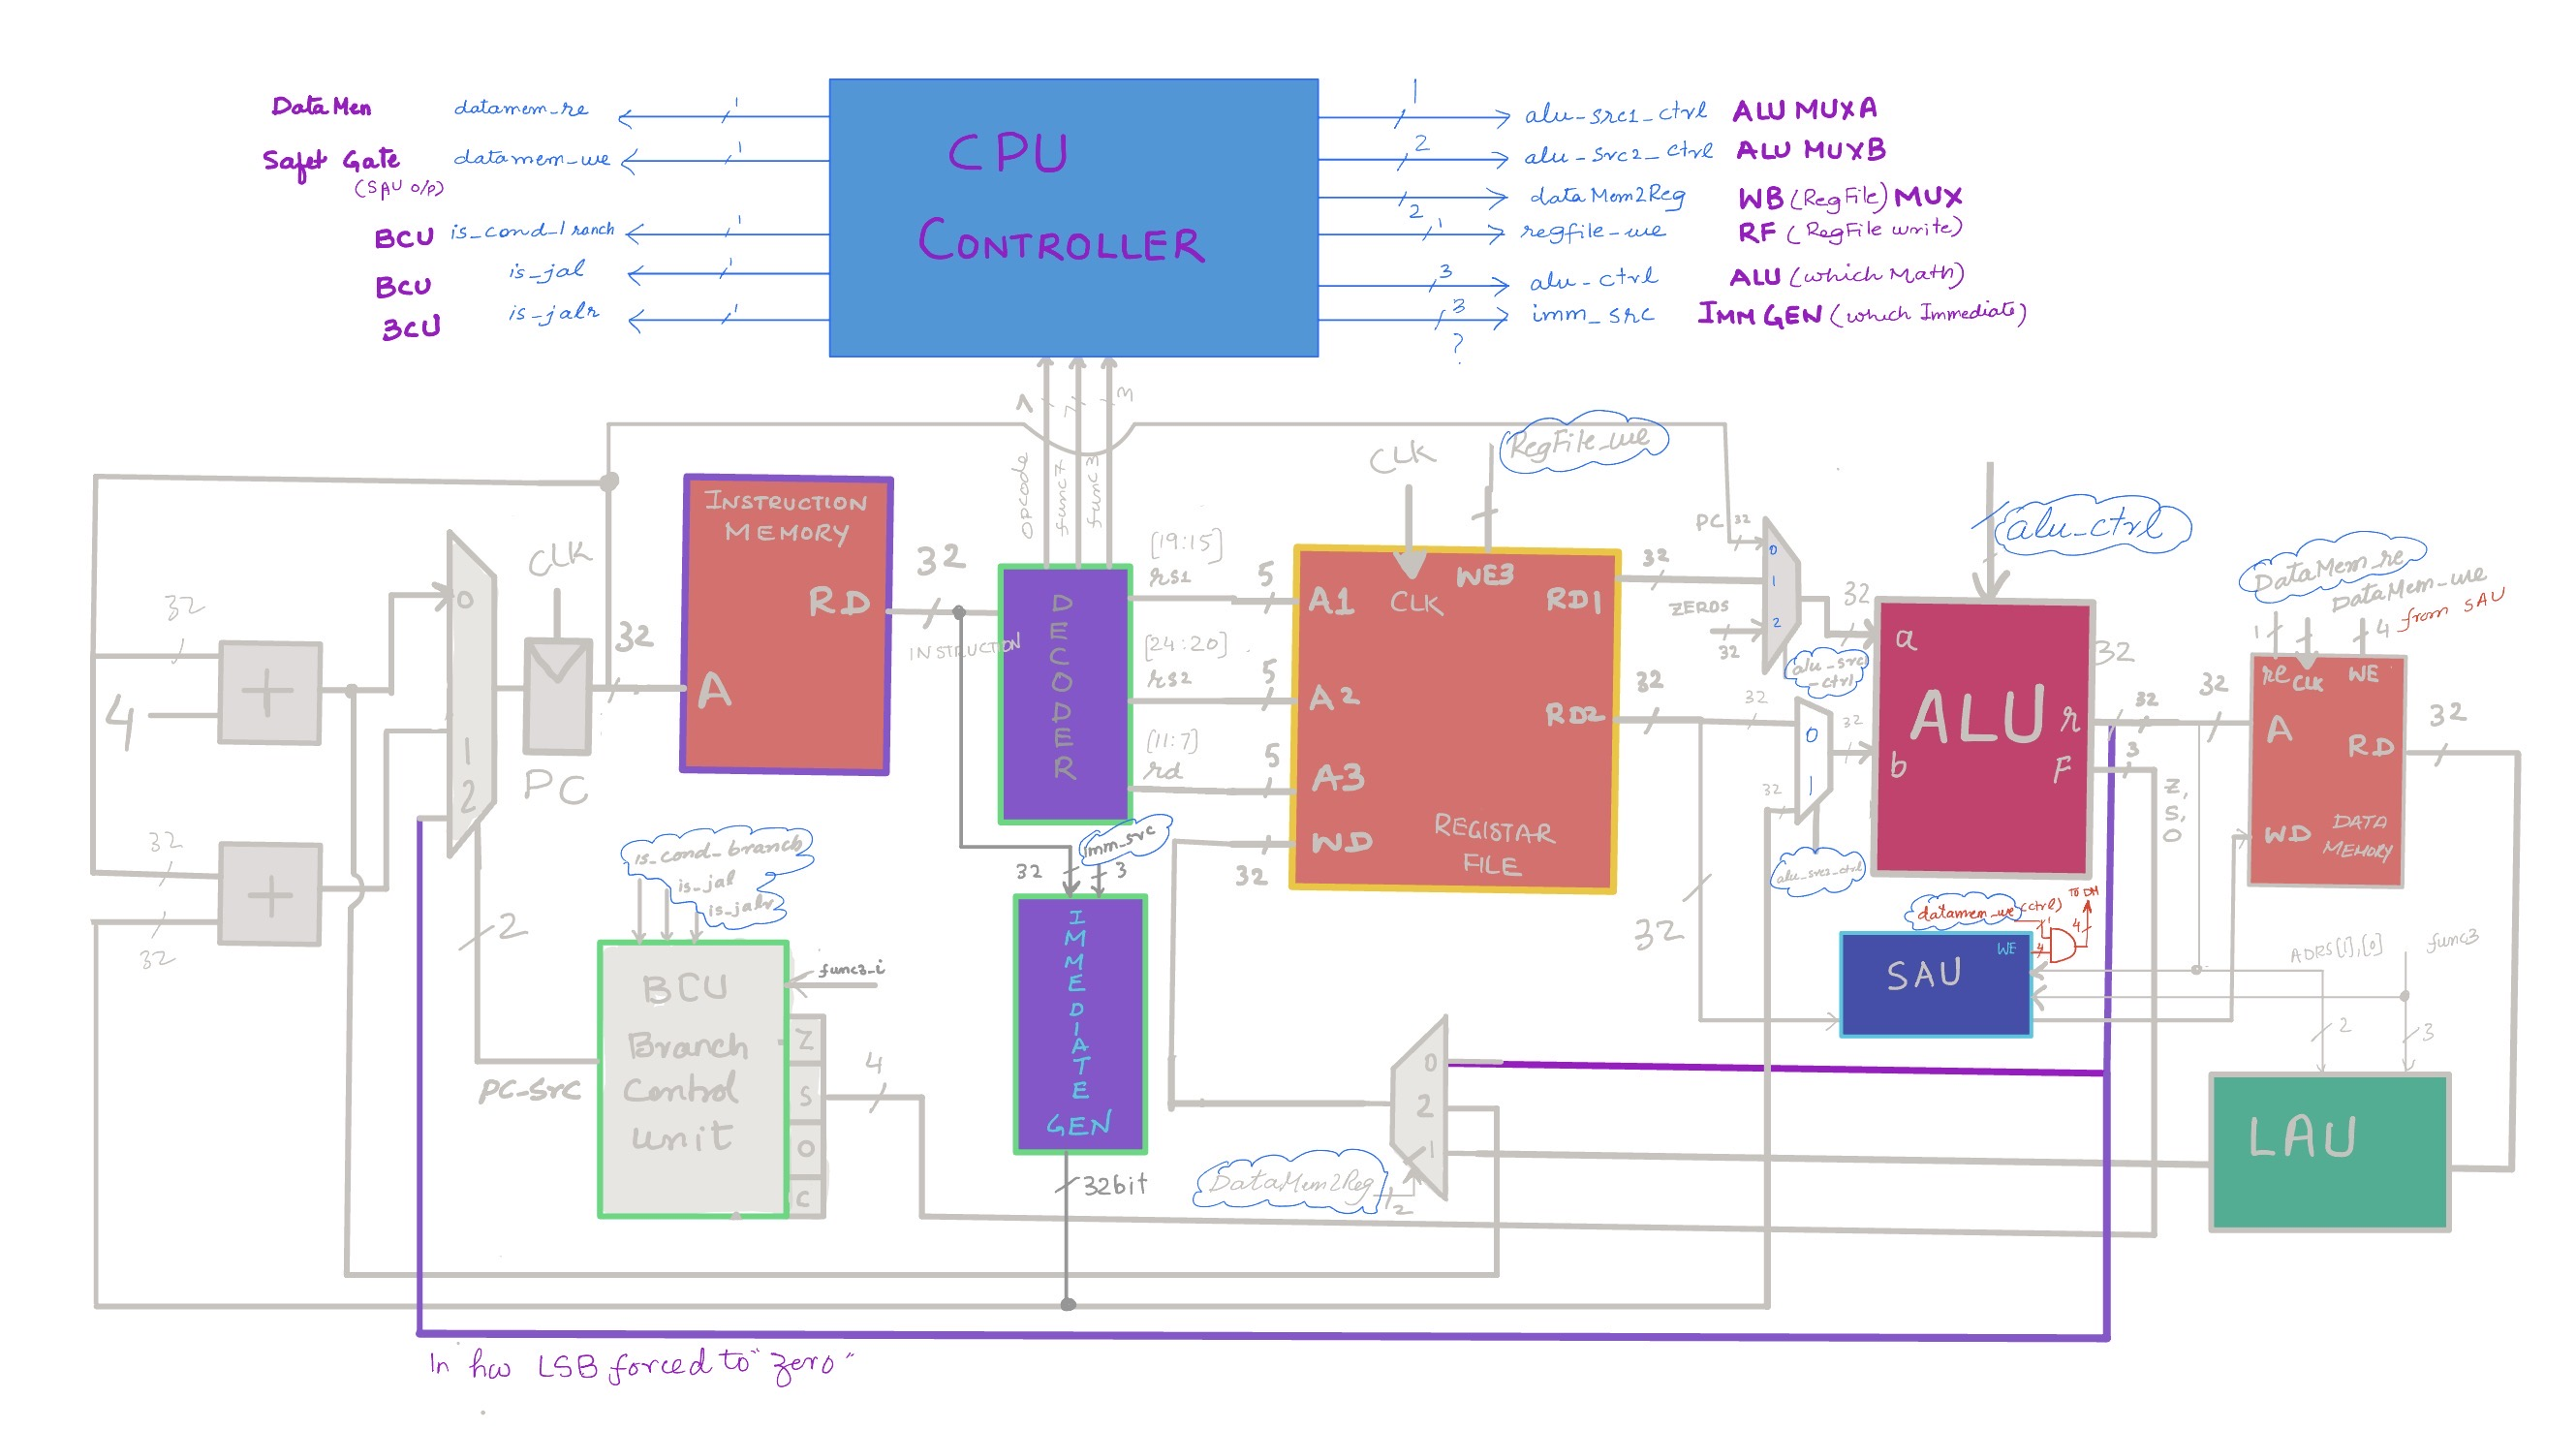

In [ ]:
%%writefile logic_test.asm
# Test
addi x1, x0, 0x078
addi x2,x1, -2048
addi x3, x1,2047
lui x4, 0x7FFFF
lui x5, 0x80000
addi x6, s0, 4
addi x7, s0, -12
addi x8, zero, 0
addi x9, zero, 2032
addi x10, zero, -78
lui x11, 0xABCDE
addi x11, x11, 0x123
lui x12, 0xFEEDB
addi x12, x12, 0x987
lui  x13, 0xFFFFF      # x1 = 0xFFFFF000 (The top of the memory map)
addi x13, x13, 2047     # x1 = 0xFFFFF000 + 0x000007FF (Max positive 12-bit)
lui  x14, 0xFFFFF      # x1 = 0xFFFFF000
addi x14, x14, 0x800    # Wait! 0x800 is -2048
# Result: 0xFFFFE800 (We went backwards)

Overwriting logic_test.asm


In [ ]:
%%writefile logic_test.expected.txt
--- Final Register State (ABI Mapping & Signed Check) ---
x00 (zero  ) : 0x00000000 (           0)
x01 (ra    ) : 0x00000078 (         120)
x02 (sp    ) : 0xfffff878 (       -1928)
x03 (gp    ) : 0x00000877 (        2167)
x04 (tp    ) : 0x7ffff000 (  2147479552)
x05 (t0    ) : 0x80000000 ( -2147483648)
x06 (t1    ) : 0x00000004 (           4)
x07 (t2    ) : 0xfffffff4 (         -12)
x08 (s0/fp ) : 0x00000000 (           0)
x09 (s1    ) : 0x000007f0 (        2032)
x10 (a0    ) : 0xffffffb2 (         -78)
x11 (a1    ) : 0xabcde123 ( -1412570845)
x12 (a2    ) : 0xfeeda987 (   -17979001)
x13 (a3    ) : 0xfffff7ff (       -2049)
x14 (a4    ) : 0xffffe800 (       -6144)
x15 (a5    ) : 0x00000000 (           0)
x16 (a6    ) : 0x00000000 (           0)
x17 (a7    ) : 0x00000000 (           0)
x18 (s2    ) : 0x00000000 (           0)
x19 (s3    ) : 0x00000000 (           0)
x20 (s4    ) : 0x00000000 (           0)
x21 (s5    ) : 0x00000000 (           0)
x22 (s6    ) : 0x00000000 (           0)
x23 (s7    ) : 0x00000000 (           0)
x24 (s8    ) : 0x00000000 (           0)
x25 (s9    ) : 0x00000000 (           0)
x26 (s10   ) : 0x00000000 (           0)
x27 (s11   ) : 0x00000000 (           0)
x28 (t3    ) : 0x00000000 (           0)
x29 (t4    ) : 0x00000000 (           0)
x30 (t5    ) : 0x00000000 (           0)
x31 (t6    ) : 0x00000000 (           0)

Overwriting logic_test.expected.txt


In [ ]:
%%writefile logic_test_1.asm
lui  x14, 0xFFFFF      # x1 = 0xFFFFF000
addi x14, x14, 0x800    # Wait! 0x800 is -2048

Overwriting logic_test_1.asm


In [ ]:
%%writefile logic_R.asm
# =========================================================================
# THE ULTIMATE R-TYPE DATAPATH TEST
# =========================================================================

# --- SETUP PHASE ---
# Loading our test operands into the lower registers
addi x1, zero, 12       # x1 = 12 (0x0000000C, Binary: 1100)
addi x2, zero, 10       # x2 = 10 (0x0000000A, Binary: 1010)
addi x3, zero, -4       # x3 = -4 (0xFFFFFFFC) - The Negative Test Subject
addi x4, zero, 2        # x4 = 2  - Our Shift Amount

# --- EXECUTION PHASE: R-TYPE OPERATIONS ---

# 1. Arithmetic (Add / Sub)
add  x20, x1, x2        # x20 = 12 + 10 = 22 (0x16)
sub  x21, x1, x2        # x21 = 12 - 10 = 2  (0x02)

# 2. Bitwise Logic (And / Or / Xor)
and  x22, x1, x2        # x22 = 1100 & 1010 = 1000 -> 8  (0x08)
or   x23, x1, x2        # x23 = 1100 | 1010 = 1110 -> 14 (0x0E)
xor  x24, x1, x2        # x24 = 1100 ^ 1010 = 0110 -> 6  (0x06)

# 3. Barrel Shifter Tests (Logical vs Arithmetic)
sll  x25, x1, x4        # x25 = 12 << 2 = 48 (0x30)
srl  x26, x3, x4        # x26 = (0xFFFFFFFC) >> 2 (Logical, pulls 0s) = 0x3FFFFFFF
sra  x27, x3, x4        # x27 = (-4) >> 2 (Arithmetic, pulls 1s) = -1 (0xFFFFFFFF)

# 4. The Comparator Tests (Signed vs Unsigned)
slt  x28, x3, x1        # x28 = (-4 < 12) Signed? True -> 1 (0x01)
sltu x29, x3, x1        # x29 = (0xFFFFFFFC < 12) Unsigned? False -> 0 (0x00)

Overwriting logic_R.asm


In [ ]:
%%writefile logic_R.expected.txt
--- Final Register State (ABI Mapping & Signed Check) ---
x01 (ra    ) : 0x0000000c (          12)
x02 (sp    ) : 0x0000000a (          10)
x03 (gp    ) : 0xfffffffc (          -4)
x04 (tp    ) : 0x00000002 (           2)
x20 (s4    ) : 0x00000016 (          22)
x21 (s5    ) : 0x00000002 (           2)
x22 (s6    ) : 0x00000008 (           8)
x23 (s7    ) : 0x0000000e (          14)
x24 (s8    ) : 0x00000006 (           6)
x25 (s9    ) : 0x00000030 (          48)
x26 (s10   ) : 0x3fffffff (  1073741823)
x27 (s11   ) : 0xffffffff (          -1)
x28 (t3    ) : 0x00000001 (           1)
x29 (t4    ) : 0x00000000 (           0)

Overwriting logic_R.expected.txt


In [ ]:
%%writefile logic_I_alu.asm
# =========================================================================
# I-TYPE ALU DATAPATH TEST
# =========================================================================

# --- SETUP PHASE ---
addi x1, zero, 12       # x1 = 12 (Binary: 1100)
addi x2, zero, -16      # x2 = -16 (0xFFFFFFF0)

# --- EXECUTION PHASE ---
# 1. Bitwise Immediate
xori x20, x1, -1        # x20 = 12 ^ -1 (Bitwise NOT). Expected: -13 (0xFFFFFFF3)
ori  x21, x1, 2         # x21 = 12 | 2. Expected: 14 (0x0000000E)
andi x22, x1, 8         # x22 = 12 & 8. Expected: 8 (0x00000008)

# 2. Shift Immediate
slli x23, x1, 2         # x23 = 12 << 2. Expected: 48 (0x00000030)
srli x24, x2, 4         # x24 = -16 >> 4 (Logical). Expected: 0x0FFFFFFF
srai x25, x2, 4         # x25 = -16 >> 4 (Arithmetic). Expected: -1 (0xFFFFFFFF)

# 3. Compare Immediate
slti x26, x1, 10        # x26 = (12 < 10) ? 1 : 0. Expected: 0

Overwriting logic_I_alu.asm


In [ ]:
%%writefile logic_I_alu.expected.txt
--- Final Register State (ABI Mapping & Signed Check) ---
x20 (s4    ) : 0xfffffff3 (         -13)
x21 (s5    ) : 0x0000000e (          14)
x22 (s6    ) : 0x00000008 (           8)
x23 (s7    ) : 0x00000030 (          48)
x24 (s8    ) : 0x0fffffff (   268435455)
x25 (s9    ) : 0xffffffff (          -1)
x26 (s10   ) : 0x00000000 (           0)

Overwriting logic_I_alu.expected.txt


In [ ]:
%%writefile logic_load.asm
# =========================================================================
# THE ULTIMATE LOAD ALIGNMENT TEST (LAU)
# =========================================================================

# --- SETUP PHASE ---
addi x10, zero, 200      # x10 = 200 (Our Base Address)

# We are going to build the word: 0x3CA5A53C
addi x1, zero, 60        # x1 = 0x3C
addi x2, zero, -91       # x2 = 0xA5 (Sign-extended)

sb x1, 0(x10)            # Mem[200] = 0x3C
sb x2, 1(x10)            # Mem[201] = 0xA5
sb x2, 2(x10)            # Mem[202] = 0xA5
sb x1, 3(x10)            # Mem[203] = 0x3C

# --- EXECUTION PHASE ---

# 1. Byte Extractions at Address 201 (The 0xA5 byte)
lb   x20, 1(x10)         # Sign-extend 0xA5. Expected: 0xFFFFFFA5 (-91)
lbu  x21, 1(x10)         # Zero-extend 0xA5. Expected: 0x000000A5 (165)

# 2. Byte Extractions at Address 200 (The 0x3C byte)
lb   x22, 0(x10)         # Sign-extend 0x3C. Expected: 0x0000003C (60)
lbu  x23, 0(x10)         # Zero-extend 0x3C. Expected: 0x0000003C (60)

# 3. Halfword Extractions (Little-Endian: Mem[1] | Mem[0] -> 0xA53C)
lh   x24, 0(x10)         # Sign-extend 0xA53C. Expected: 0xFFFFA53C (-23236)
lhu  x25, 0(x10)         # Zero-extend 0xA53C. Expected: 0x0000A53C (42300)

# 4. The Full Word Extraction
lw   x26, 0(x10)         # Pass through. Expected: 0x3CA5A53C (1017488700)

Overwriting logic_load.asm


In [ ]:
%%writefile logic_load.expected.txt
--- Final Register State (ABI Mapping & Signed Check) ---
x20 (s4    ) : 0xffffffa5 (         -91)
x21 (s5    ) : 0x000000a5 (         165)
x22 (s6    ) : 0x0000003c (          60)
x23 (s7    ) : 0x0000003c (          60)
x24 (s8    ) : 0xffffa53c (      -23236)
x25 (s9    ) : 0x0000a53c (       42300)
x26 (s10   ) : 0x3ca5a53c (  1017488700)

Overwriting logic_load.expected.txt


In [ ]:
%%writefile logic_store.asm
# =========================================================================
# S-TYPE STORE ALIGNMENT TEST (SAU)
# =========================================================================

# --- SETUP PHASE ---
addi x10, zero, 300      # x10 = 300 (Our Base Memory Address)

# Update these three lines to match the new expectations:
addi x1, zero, -1        # x1 = 0xFFFFFFFF (Fill with 1s)
addi x2, zero, 0x55      # x2 = 0x00000055 (Byte: 85. Well within max 2047)
addi x3, zero, 0x777     # x3 = 0x00000777 (Halfword: 1911. Well within max 2047)

# --- EXECUTION PHASE ---

# 1. Store the full word
sw   x1, 0(x10)          # Mem[300] = 0xFFFFFFFF. Strobe should be 1111.

# 2. Overwrite the top halfword (Bytes 2 and 3)
# We store at address 300 + 2. The SAU should generate strobe 1100.
sh   x3, 2(x10)          # Mem[300] becomes 0x0888FFFF

# 3. Overwrite Byte 1
# We store at address 300 + 1. The SAU should generate strobe 0010.
sb   x2, 1(x10)          # Mem[300] becomes 0x088877FF

# --- VERIFICATION PHASE ---
# Load the full word back out to prove the bytes merged correctly
lw   x20, 0(x10)         # x20 should perfectly equal 0x088877FF (143161343)

Overwriting logic_store.asm


In [ ]:
%%writefile logic_store.expected.txt
--- Final Register State (ABI Mapping & Signed Check) ---
x01 (ra    ) : 0xffffffff (          -1)
x02 (sp    ) : 0x00000055 (          85)
x03 (gp    ) : 0x00000777 (        1911)
x10 (a0    ) : 0x0000012c (         300)
x20 (s4    ) : 0x077755ff (   125261311)

--- Final Data Memory State (Sparse Dump) ---
Mem[0x0000012c] : 0x077755ff

Overwriting logic_store.expected.txt


In [ ]:
%%writefile logic_auipc.asm
# =========================================================================
# U-TYPE AUIPC BOUNDARY & PC ALIGNMENT TEST
# =========================================================================

# Assuming execution begins at PC = 0x00000000

# 1. The Minimum Boundary Check (Immediate = 0)
# Execution PC = 0
auipc x20, 0             # x20 = 0 + (0 << 12) = 0x00000000

# 2. Standard Shift Check (Immediate = 1)
# Execution PC = 4
auipc x21, 1             # x21 = 4 + (1 << 12) = 0x00001004 (4100)

# 3. The Maximum Boundary Check (Immediate = 0xFFFFF)
# Execution PC = 8
# 0xFFFFF << 12 = 0xFFFFF000 (which is -4096 in 32-bit signed space)
auipc x22, 0xFFFFF       # x22 = 8 + 0xFFFFF000 = 0xFFFFF008 (-4088)

Overwriting logic_auipc.asm


In [ ]:
%%writefile logic_auipc.expected.txt
--- Final Register State (ABI Mapping & Signed Check) ---
x20 (s4    ) : 0x00000000 (           0)
x21 (s5    ) : 0x00001004 (        4100)
x22 (s6    ) : 0xfffff008 (       -4088)

Overwriting logic_auipc.expected.txt


In [ ]:
%%writefile logic_bnejump.asm
# =========================================================================
# TURING COMPLETENESS TEST: THE WHILE LOOP
# =========================================================================

# --- SETUP ---
addi x5, zero, 5      # x5 = 5 (Our loop counter)
addi x6, zero, 0      # x6 = 0 (Our running total)

# --- THE LOOP ---
# Memory Address 0x08 (Assuming execution started at 0x00)
add  x6, x6, x5       # total = total + counter
addi x5, x5, -1       # counter = counter - 1
bne  x5, zero, -8     # IF counter != 0, Jump back 8 bytes (2 instructions) to 0x08!

# --- END ---
# When the loop breaks, the CPU lands here.
addi x7, zero, 99     # x7 = 99 (Marker to prove we escaped the loop)

Overwriting logic_bnejump.asm


In [ ]:
%%writefile logic_bnejump.expected.txt
--- Final Register State (ABI Mapping & Signed Check) ---
x05 (t0    ) : 0x00000000 (           0)
x06 (t1    ) : 0x0000000f (          15)
x07 (t2    ) : 0x00000063 (          99)

Overwriting logic_bnejump.expected.txt


In [ ]:
%%writefile logic_branch.asm
# =========================================================================
# B-TYPE: COMPREHENSIVE BRANCH CONTROL UNIT TEST
# =========================================================================

# --- SETUP PHASE (Testing Max/Min Boundaries) ---
addi x1, zero, 10       # x1 = 10
addi x2, zero, 10       # x2 = 10
addi x3, zero, -2048    # x3 = -2048 (0xFFFFF800 - Minimum boundary)
addi x4, zero, 2047     # x4 = 2047  (0x000007FF - Maximum boundary)

# Initialize our result registers to 1 (Assuming PASS)
addi x20, zero, 1
addi x21, zero, 1
addi x22, zero, 1
addi x23, zero, 1
addi x24, zero, 1
addi x25, zero, 1

# --- EXECUTION: TAKEN BRANCH TESTS (Should Skip 8 bytes) ---

# 1. BEQ (Equal): 10 == 10
beq  x1, x2, 8
addi x20, zero, 0       # FAIL: Overwrites with 0 if branch missed

# 2. BNE (Not Equal): -2048 != 2047
bne  x3, x4, 8
addi x21, zero, 0       # FAIL: Overwrites with 0 if branch missed

# 3. BLT (Less Than Signed): -2048 < 10
blt  x3, x1, 8
addi x22, zero, 0       # FAIL: Overwrites with 0 if branch missed

# 4. BGE (Greater/Equal Signed): 2047 >= 10
bge  x4, x1, 8
addi x23, zero, 0       # FAIL: Overwrites with 0 if branch missed

# 5. BLTU (Less Than Unsigned)
# -2048 in hardware is 0xFFFFF800. Unsigned, this is 4,294,965,248.
# Therefore, 10 < 4,294,965,248 is TRUE.
bltu x1, x3, 8
addi x24, zero, 0       # FAIL: Overwrites with 0 if branch missed

# 6. BGEU (Greater/Equal Unsigned)
# 4,294,965,248 >= 10 is TRUE.
bgeu x3, x1, 8
addi x25, zero, 0       # FAIL: Overwrites with 0 if branch missed

# --- EXECUTION: NOT TAKEN TEST (Should Fall Through) ---
# We must also prove the CPU doesn't jump when the condition is FALSE.
addi x26, zero, 0       # Initialize to 0 (Assume FAIL)
beq  x1, x4, 8          # 10 == 2047? FALSE. It should fall through!
addi x26, zero, 1       # PASS: Overwrites with 1 because it correctly fell through

Overwriting logic_branch.asm


In [ ]:
%%writefile logic_branch.expected.txt
--- Final Register State (ABI Mapping & Signed Check) ---
x01 (ra    ) : 0x0000000a (          10)
x02 (sp    ) : 0x0000000a (          10)
x03 (gp    ) : 0xfffff800 (       -2048)
x04 (tp    ) : 0x000007ff (        2047)
x20 (s4    ) : 0x00000001 (           1)
x21 (s5    ) : 0x00000001 (           1)
x22 (s6    ) : 0x00000001 (           1)
x23 (s7    ) : 0x00000001 (           1)
x24 (s8    ) : 0x00000001 (           1)
x25 (s9    ) : 0x00000001 (           1)
x26 (s10   ) : 0x00000001 (           1)

Overwriting logic_branch.expected.txt


In [ ]:
%%writefile logic_jump.asm
# =========================================================================
# THE FINAL MILESTONE: JAL & JALR (Function Calls)
# =========================================================================

# --- MAIN PROGRAM ---
# PC = 0x00
addi x5, zero, 15       # x5 = 15 (Our input)

# PC = 0x04
# Call the function at 0x10 (Offset = 12 bytes)
# Saves return address (0x08) into x1
jal  x1, 12

# PC = 0x08 (The Return Point)
addi x6, zero, 99       # x6 = 99 (Marker to prove we returned!)

# PC = 0x0C
beq  zero, zero, 0      # Infinite loop to stay at 0x0C (Stop execution)

# --- FUNCTION: DOUBLE IT ---
# PC = 0x10
add  x5, x5, x5         # x5 = 15 + 15 = 30

# PC = 0x14
# Jump back to the address in x1 (0x08)
jalr x0, 0(x1)

Overwriting logic_jump.asm


In [ ]:
%%writefile logic_jump.expected.txt
--- Final Register State (ABI Mapping & Signed Check) ---
x01 (ra    ) : 0x00000008 (           8)
x05 (t0    ) : 0x0000001e (          30)
x06 (t1    ) : 0x00000063 (          99)

Overwriting logic_jump.expected.txt


O'SoC1 Top

In [ ]:
# ==============================================================================
# CELL 6: THE STRUCTURAL TOP-LEVEL (Hardware-Mapped Netlist)
# ==============================================================================
dump_file = 'python_golden_state.txt'
ref_file  = 'logic_jump.expected.txt'
# --- PHASE 1: SOFTWARE TOOLCHAIN (Assembler) ---
asm_file = 'logic_jump.asm'
hex_file = 'program.hex'
total_instructions = generate_hex_file(asm_file, hex_file)

# --- PHASE 2: HARDWARE INITIALIZATION (Power-On) ---
instruction_memory = InstructionMemory()
reg_file = RegisterFile()
data_memory = DataMemory()

# Load the "SRAM" with our machine code
instruction_memory.load_from_hex_file(hex_file)

# Initialize the PC Hardware Register
pc_reg_storage = PCState()
pc_next = 0x00000000
enable_pc = 1
reset_pc = 1  # POWER-ON RESET IS ACTIVE

rf_wd   = 0x00000000  # The global Write-Back Data bus

print(f"\n🚀 Starting Structural Simulation of {total_instructions} instructions...\n")

# --- SIMULATION WATCHDOG TIMER (MAXIMUM BOUNDARY) ---
MAX_CYCLES = 100  # Set this high enough for your loop to finish!

# --- PHASE 3: THE CLOCK LOOP ---
for cycle in range(MAX_CYCLES):

    print(f"[{'='*25} Cycle {cycle} {'='*25}]")
    # 0. THE CLOCK EDGE (PC Register Update)
    # ---------------------------------------------------------
    pc_curr = module_pc_reg(pc_next, enable_pc, reset_pc, pc_reg_storage)
    print(f"\n\nFETCH      | PC: 0x{pc_curr:08x}\n")

    if cycle == 0:
        print(f"[{'='*25} Cycle {cycle} (RESET) {'='*25}]")
        print("  --- HARDWARE RESET RELEASED ---")
        reset_pc = 0 # Release reset for the rest of the simulation
        continue     # Skip execution for this setup cycle



    # 1. FETCH (Instruction Tier)
    # ---------------------------------------------------------
    instr_i = module_instruction_memory(pc_curr, instruction_memory)

    # Natural HALT Condition: If we fetch 0x00000000, memory is empty.
    if instr_i == 0:
        print(f"🛑 HALT: Empty memory reached at PC 0x{pc_curr:08x}.")
        break


    pc_plus_4_i = module_pc_plus_4(pc_curr)

    # 2. DECODE & CONTROL (Control Tier)
    # ---------------------------------------------------------
    op_o, rd_o, rs1_o, rs2_o, f3_o, f7_o, imm_o = module_decoder(instr_i)

    asm_str_o = debug_disassemble(op_o, rd_o, rs1_o, rs2_o, f3_o, f7_o, imm_o)

    signals_o = module_ctrl(op_o, f3_o, f7_o)
    (is_br, is_jal, is_jalr, imm_src, s1_sel, s2_sel,
     alu_op, mem_re, mem_we, d2r, rf_we) = signals_o

    print(f"\n\nFETCH      | PC: 0x{pc_curr:08x} | INSTR: 0x{instr_i:08x}")
    print(f"DISASM     | {asm_str_o}\n\n")

    # 3. REGISTER FILE READ (The Blue Wires)
    # ---------------------------------------------------------
    # Note: We pass rd_o/rf_wd here to allow for the module to handle logic,
    # but the actual write happens at the end of the cycle.
    rs1_val, rs2_val = module_register_file(rs1_o, rs2_o, rd_o, rf_wd, 0, reg_file)

    # 4. EXECUTION (Execution Tier)
    # ---------------------------------------------------------
    # A. Input Selection (Orange Box)
    alu_a, alu_b = module_alu_in_muxes(pc_curr, rs1_val, rs2_val, imm_o, s1_sel, s2_sel)

    # B. ALU Core (Pink Box)
    alu_res, z_o, s_o, ov_o, carry_o = module_alu(alu_a, alu_b, alu_op)
    flags_o = (z_o, s_o, ov_o, carry_o)

    # 5. DATA MEMORY TIER (Memory Sub-system)
    # ---------------------------------------------------------
    # Physical Bus Fan-out: A[1:0] tapped from ALU Result
    adrs_1 = (alu_res >> 1) & 1
    adrs_0 = alu_res & 1

    # A. Store Alignment (Purple Box) -> Generates Data + 4-bit Strobe
    aligned_wdata, we_strobe = module_sau(rs2_val, adrs_1, adrs_0, f3_o)

    # B. SRAM Macro Access (Physical Storage)
    raw_mem_data = module_data_memory(alu_res, aligned_wdata, we_strobe, mem_re, mem_we, data_memory)

    # C. Load Alignment (Brown Box) -> Extracts Byte/Half and Sign-Extends
    lau_res = module_lau(raw_mem_data, adrs_1, adrs_0, f3_o)

    # 6. WRITE-BACK SELECTION (Yellow Box)
    # ---------------------------------------------------------
    rf_wd = module_rf_wb_mux(alu_res, lau_res, pc_plus_4_i, d2r)

    # 7. THE CLOCK EDGE (Commit Phase)
    # ---------------------------------------------------------
    # Write result back to Register File
    if rf_we:
        module_register_file(rs1_o, rs2_o, rd_o, rf_wd, rf_we, reg_file)

    # Update PC for next cycle
    pc_src_o = module_bcu(f3_o, flags_o, is_br, is_jal, is_jalr)
    pc_next  = module_next_pc_logic(pc_curr, pc_plus_4_i, imm_o, alu_res, pc_src_o)


    print(f"After Clock Edge, new PC : 0x{pc_next:08x}")
    print("-" * 75)

# --- PHASE 4: POST-MORTEM DUMP & REGRESSION ---


ABI_NAMES = [
    'zero', 'ra', 'sp', 'gp', 'tp', 't0', 't1', 't2',
    's0/fp', 's1', 'a0', 'a1', 'a2', 'a3', 'a4', 'a5',
    'a6', 'a7', 's2', 's3', 's4', 's5', 's6', 's7',
    's8', 's9', 's10', 's11', 't3', 't4', 't5', 't6'
]

with open(dump_file, 'w') as f:
    # 1. Dump the Register File
    f.write(f"--- Final Register State (ABI Mapping & Signed Check) ---\n")
    for i in range(32):
        val_hex = reg_file.read_rs1(i) & 0xFFFFFFFF
        val_dec = val_hex if val_hex < 0x80000000 else val_hex - 0x100000000
        abi_name = ABI_NAMES[i]
        f.write(f"x{i:02d} ({abi_name:<6}) : 0x{val_hex:08x} ({val_dec:>12d})\n")

    # 2. Dump the Sparse Data Memory
    f.write(f"\n--- Final Data Memory State (Sparse Dump) ---\n")
    # We sort the keys so the output is always deterministic for our regression checker
    for addr in sorted(data_memory.memory.keys()):
        val_hex = data_memory.memory[addr]
        f.write(f"Mem[0x{addr:08x}] : 0x{val_hex:08x}\n")

print(f"\n💾 Final state saved to {dump_file}")

# Targeted Regression Check (Handles Sparse Reference Files)
test_passed = False
test_passed = verify_cpu_results(dump_file, ref_file)

if test_passed:
    print(f"\n🚀 ARCHITECTURE VERIFIED: Actual matches Golden Reference.")
else:
    print(f"\n❗ ARCHITECTURE REGRESSION: Check the mismatch log above.")

✅ Success: program.hex generated (6 instructions).

🚀 Starting Structural Simulation of 6 instructions...

[========================= Cycle 0 =========================]


FETCH      | PC: 0x00000000

[========================= Cycle 0 (RESET) =========================]
  --- HARDWARE RESET RELEASED ---
[========================= Cycle 1 =========================]


FETCH      | PC: 0x00000000


--- inside the module module_decoder ---
OUTPUTS | op: 19 | rd: 5 | rs1: 0 | rs2: 15
        | f3: 0 | f7: 0 | imm: 0x0000000f (15)

--- inside the module module_ctrl ---
INPUTS  | op_i: 19 | f3_i: 0 | f7_i: 0
OUTPUTS | Mem: [RE:0, WE:0]
        | BCU [IS-COND-BRANCH:0, IS_JAL:0, IS_JALR:0]
        | Data: [ImmSrc:0, S1:1, S2:1, ALU:ADD, D2R:0, RFWE:1]


FETCH      | PC: 0x00000000 | INSTR: 0x00f00293
DISASM     | addi x5(t0), x0(zero), 15



**** Inside RF ******
INPUTS  | rs1_addr: 0 | rs2_addr: 15 | rd_addr: 5
        | rf_we: 0 | rd_data: 0x00000000
OUTPUTS | rs1_val: 0x00000000 | rs2_val: 0